## Módulo 19 - Transformação de Variáveis


# Projeto de Regressão Linear: Precificação de Imóveis

## Objetivo
Estimar preços dos imóveis de acordo com diversas características das propriedades, como área e localização. Para este propósito, vamos:

* **Identificar** quais fatores contribuem para a precificação dos imóveis;
* **Averiguar** a influência das características no preço do imóvel;
* **Diferenciar** quando precisamos transformar ou não as variáveis para uma melhor resposta do modelo;
* **Verificar** a relação entre as variáveis explicativas e a variável resposta;
* **Criar** um modelo de regressão linear de múltiplas variáveis;
* **Fazer** previsões para uma ou mais casas.

## Base de Dados
Vamos utilizar a base `precos_casa.csv`, adaptada de uma base bem conhecida no Kaggle chamada [House Prices](https://kaggle.com). Esses dados serão lidos a partir do repositório compartilhado pelo GitHub.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# Alternativa caso o link falhe: usando seu arquivo local
dados = pd.read_csv(r'Dados\precos_casas.csv')

# Filtrando e ordenando as colunas
ordem_colunas = ['valor', 'area_primeiro_andar', 'existe_segundo_andar', 'area_quintal', 'dist_metro', 'dist_parque']
dados = dados[ordem_colunas].round(2)
dados.head()




,valor,area_primeiro_andar,existe_segundo_andar,area_quintal,dist_metro,dist_parque
0,1042500,79.52,1,23.86,1.64,3.04
1,907500,117.24,0,35.17,1.54,10.91
2,1117500,85.47,1,25.64,1.27,11.79
3,700000,89.28,1,21.07,1.22,10.88
4,1250000,106.37,1,31.91,0.87,11.25


In [4]:
dados.shape

(1460, 6)

In [5]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   valor                 1460 non-null   int64  
 1   area_primeiro_andar   1460 non-null   float64
 2   existe_segundo_andar  1460 non-null   int64  
 3   area_quintal          1460 non-null   float64
 4   dist_metro            1460 non-null   float64
 5   dist_parque           1460 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 68.6 KB


# 1.3 - Entendendo a relação dos dados

Para entender a relação dos dados entre o valor de venda dos imóveis do dataset e suas características vamos utilizar a **Correlação**.

Correlação é uma medida estatística que varia numa escala de -1 a 1, indicando a relação e a dependência entre duas variáveis. Existem três tipos principais de correlação:

1. **Correlação Positiva**: quando uma variável aumenta, a outra tende a aumentar.
2. **Correlação Nula**: não há relação linear entre as variáveis.
3. **Correlação Negativa**: quando uma variável aumenta, a outra tende a diminuir.

Essa medida não só define a direção, como também, a intensidade da relação.


In [6]:
# .corr(): Calcula os coeficientes de correlação linear entre todas as colunas numéricas
# .round(3): Arredonda os valores resultantes para exibir exatamente 3 casas decimais
corr = dados.corr().round(3)

# Exibe a matriz de correlação gerada na tela do notebook
corr


,valor,area_primeiro_andar,existe_segundo_andar,area_quintal,dist_metro,dist_parque
valor,1.000,0.606,0.138,0.614,-0.644,-0.072
area_primeiro_andar,0.606,1.000,-0.339,0.820,-0.369,-0.058
existe_segundo_andar,0.138,-0.339,1.000,-0.301,-0.191,-0.007
area_quintal,0.614,0.820,-0.301,1.000,-0.440,-0.058
dist_metro,-0.644,-0.369,-0.191,-0.440,1.000,0.089
dist_parque,-0.072,-0.058,-0.007,-0.058,0.089,1.000


In [7]:
# corr["valor"]: Filtra apenas a coluna de preço ('valor') dentro da matriz de correlação
# .to_frame(): Transforma a série resultante em uma tabela (DataFrame) para ficar mais visual
corr["valor"].to_frame()


,valor
valor,1.000
area_primeiro_andar,0.606
existe_segundo_andar,0.138
area_quintal,0.614
dist_metro,-0.644
dist_parque,-0.072


# 1.4 - Visualizando uma Regressão Linear com uma variável independente

Já compreendemos um pouco a relação entre as variáveis e o valor de venda das casas. Mas que tal observarmos isso visualmente, pegando apenas uma das variáveis de nossa base?

>Aqui vamos apenas observar o comportamento da variável `valor` em relação a `area_primeiro_andar` rodando um modelo de regressão linear dentro da função `reg_plot()` da biblioteca `seaborn`. Mais a frente implementaremos o nosso próprio modelo!


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

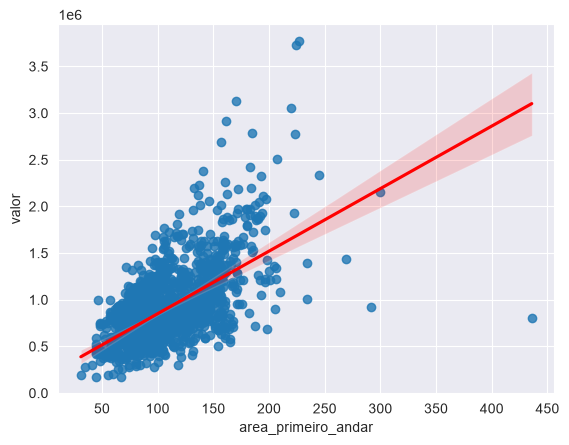

In [9]:
sns.set_style("darkgrid")
sns.regplot(x="area_primeiro_andar", y="valor", data=dados, line_kws={'color':'red'})
plt.show()

In [12]:
# Importa as ferramentas necessárias para renderizar Markdown dentro do código Python
from IPython.display import display, Markdown

# Armazena todo o texto explicativo e as fórmulas em formato string
conteudo_teorico = """
### 1.5 - A Equação da Regressão Linear Simples

A fórmula matemática que descreve o modelo de regressão linear que acabamos de visualizar graficamente é definida por:

$$Y = \\beta_0 + \\beta_1 X + e$$

Onde cada componente representa:

* **$Y$ (Variável Resposta)**: É a variável dependente que queremos prever (no nosso caso, o `valor` do imóvel).
* **$\\beta_0$ (Intercepto)**: O ponto onde a linha de regressão corta o eixo Y.
* **$\\beta_1$ (Coeficiente Angular)**: A inclinação da reta, indicando o impacto de $X$ em $Y$.
* **$X$ (Variável Explicativa)**: A variável independente usada para fazer a previsão (a `area_primeiro_andar`).
* **$e$ (Erro)**: O resíduo (diferença entre o valor real e o previsto).
"""

# Renderiza e exibe o bloco formatado perfeitamente na tela
display(Markdown(conteudo_teorico))



### 1.5 - A Equação da Regressão Linear Simples

A fórmula matemática que descreve o modelo de regressão linear que acabamos de visualizar graficamente é definida por:

$$Y = \beta_0 + \beta_1 X + e$$

Onde cada componente representa:

* **$Y$ (Variável Resposta)**: É a variável dependente que queremos prever (no nosso caso, o `valor` do imóvel).
* **$\beta_0$ (Intercepto)**: O ponto onde a linha de regressão corta o eixo Y.
* **$\beta_1$ (Coeficiente Angular)**: A inclinação da reta, indicando o impacto de $X$ em $Y$.
* **$X$ (Variável Explicativa)**: A variável independente usada para fazer a previsão (a `area_primeiro_andar`).
* **$e$ (Erro)**: O resíduo (diferença entre o valor real e o previsto).
